In [70]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [71]:
image = cv2.imread('sar_1.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 

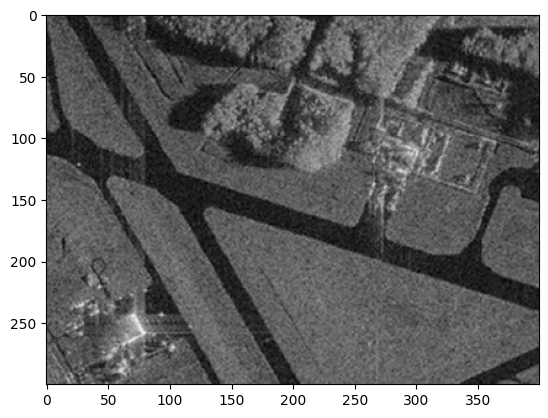

In [72]:
plt.imshow(image_gray, cmap="gray")

# Алгоритм разрастания регионов

In [73]:
import math
def homo_average(img, mask, point, T):
    av_val = img[mask > 0].sum() / np.count_nonzero(img[mask > 0])
                                                            
    if abs(av_val - img[point]) <= T:
        return True
    
    return False
    

In [74]:
def region_growing(image, seed_point,homo_fun,r, T):
    mask = np.zeros(image_gray.shape, np.uint8)
    mask[seed_point] = 1
    count = 1
    while count > 0:
        count = 0
        local_mask = np.zeros(image_gray.shape, np.uint8)
        for i in range(r,image.shape[0] - r):
            for j in range(r,image.shape[1] - r):
                if mask[i,j]==0 and mask[i - r:i + r, j-r: j+r].sum() > 0:
                    if homo_fun(image, mask, (i,j), T):
                        local_mask[i,j] = 1
        count = np.count_nonzero(local_mask)
        print(count)
        mask += local_mask
        
    return mask*255
    

In [75]:
seed_point = (250,250)
mask = region_growing(image_gray,seed_point,homo_average,1, 10)

3
4
4
5
7
6
6
9
7
6
6
9
13
12
15
17
13
13
16
16
14
16
15
16
10
11
14
13
14
10
10
14
17
15
36
22
21
18
21
21
25
23
43
31
34
23
20
27
29
35
40
32
35
42
48
52
30
23
20
19
19
20
18
22
74
24
26
29
30
27
29
29
28
29
20
17
17
21
20
25
23
24
20
18
19
15
18
18
15
18
13
10
9
7
9
9
10
11
12
10
12
11
8
9
7
4
3
6
6
6
5
5
5
3
2
2
2
1
0


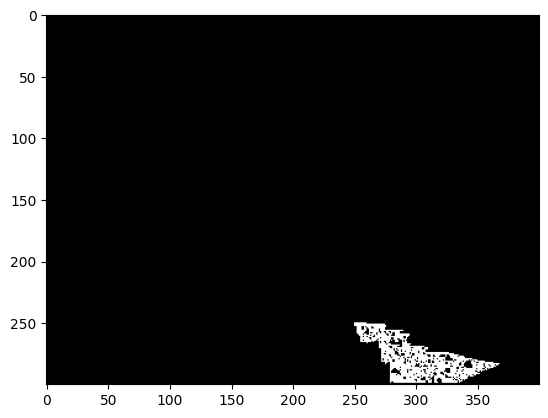

In [76]:
plt.imshow(mask, cmap="gray")

# K-means

In [77]:
# Define criteria = ( type, max_iter = 10 , epsilon = 1.0 )
# criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 10, 1.0)

In [78]:
flags = cv2.KMEANS_RANDOM_CENTERS

In [79]:
z = image_gray.reshape((-1,3))
# convert to np.float32
z = np.float32(z)
# define criteria, number of clusters(K) and apply kmeans()
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
K = 3
ret,label,center=cv2.kmeans(z,K,None,criteria,10,cv2.KMEANS_RANDOM_CENTERS)
# Now convert back into uint8, and make original image
center = np.uint8(center)
res = center[label.flatten()]
res2 = res.reshape((image_gray.shape))

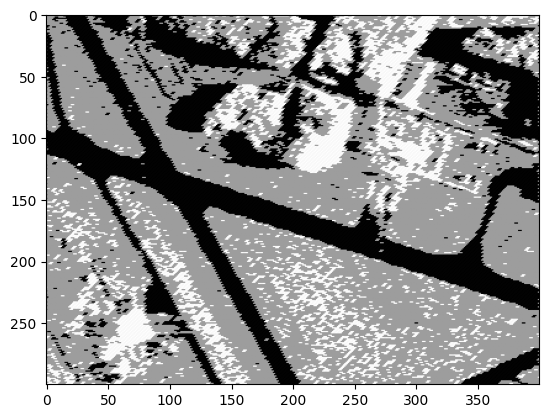

In [80]:
plt.imshow(res2, cmap="gray")

# Watershed+Distance transform

In [81]:
image = cv2.imread('oranges_1.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 

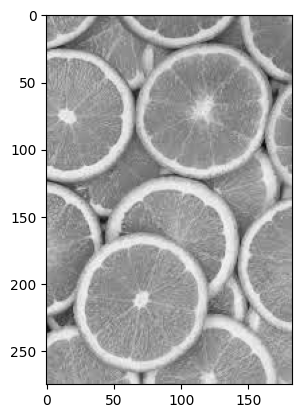

In [82]:
plt.imshow(image_gray, cmap="gray")

In [83]:
ret, thresh = cv2.threshold(image_gray,0,255, cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)

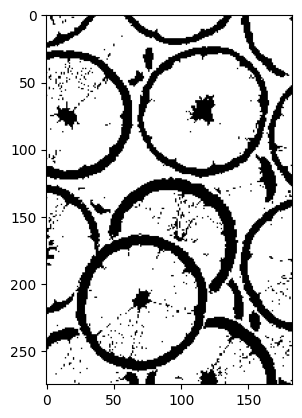

In [84]:
plt.imshow(thresh, cmap="gray")

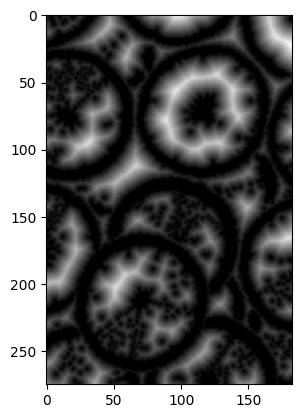

In [85]:
dist = cv2.distanceTransform(thresh, cv2.DIST_L2, 5) 
plt.imshow(dist, cmap="gray")

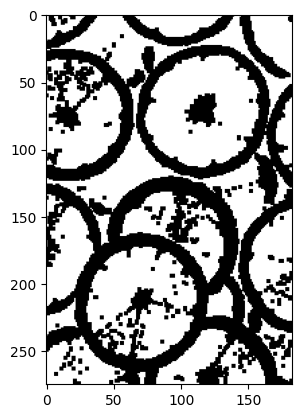

In [86]:
ret, sure_fg = cv2.threshold(dist, 0.1 * dist.max(), 255, cv2.THRESH_BINARY) 
plt.imshow(sure_fg, cmap="gray")

In [87]:
sure_fg = sure_fg.astype(np.uint8)

In [88]:
ret, markers = cv2.connectedComponents(sure_fg) 

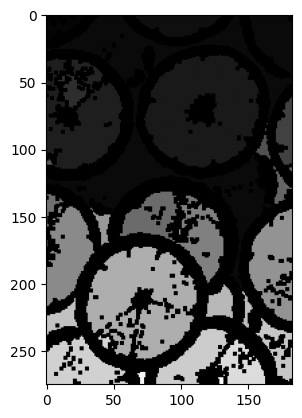

In [89]:
plt.imshow(markers, cmap="gray")

In [90]:
markers = cv2.watershed(image, markers)

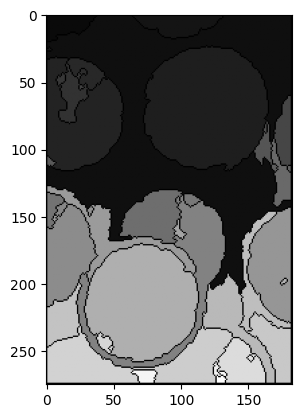

In [91]:
plt.imshow(markers, cmap="gray")

In [92]:
# ДЗ
# 1. Подберите парамтеры алгоритма разрастания регионов так, чтобы был выделен весь участок газона.
# 2. Реализуйте вычисление критерия однородности, отличного от представленного. Сравните результаты.
# 3. Применить алгоритм сегментации watershed+distance transform для задачи подсчета пальмовых деревьев.

### 1. Подберите парамтеры алгоритма разрастания регионов так, чтобы был выделен весь участок газона.

In [93]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import math

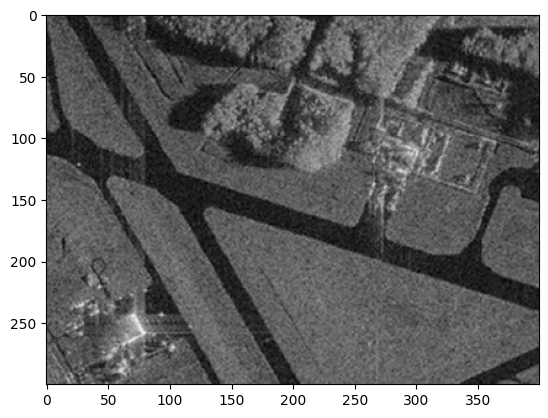

In [94]:
image = cv2.imread('sar_1.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.imshow(image_gray, cmap="gray")

In [ ]:
# Функция проверки однородности на основе среднего
def homo_average(img, mask, point, T):
    # Вычисление среднего значения в текущем регионе
    region_values = img[mask > 0]
    if len(region_values) == 0:
        return False  # На случай пустой маски, хотя не должно быть
    av_val = region_values.sum() / len(region_values)
    # Проверка, укладывается ли значение пикселя в порог
    if abs(av_val - img[point]) <= T:
        return True
    return False

# Алгоритм роста регионов
def region_growing(image, seed_point, homo_fun, r, T):
    mask = np.zeros(image.shape, np.uint8)
    mask[seed_point] = 1
    count = 1
    iteration = 0
    while count > 0:
        iteration += 1
        count = 0
        local_mask = np.zeros(image.shape, np.uint8)
        for i in range(r, image.shape[0] - r):
            for j in range(r, image.shape[1] - r):
                if mask[i, j] == 0 and np.sum(mask[i - r:i + r + 1, j - r:j + r + 1]) > 0:
                    if homo_fun(image, mask, (i, j), T):
                        local_mask[i, j] = 1
        count = np.count_nonzero(local_mask)
        mask += local_mask
    final_size = np.count_nonzero(mask)
    print(f"Завершено для (r={r}, T={T}): Общий размер региона - {final_size} пикселей\n")
    return mask * 255

# Список пар параметров (r, T)
param_pairs = [(1, 10), (2, 30), (3, 35)]
seed_point = (250, 250)

fig, axs = plt.subplots(1, len(param_pairs), figsize=(15, 5))
fig.suptitle("Сегментация газона с разными параметрами (r, T)", fontsize=16)

# Запуск для каждой пары и визуализация
for idx, (r, T) in enumerate(param_pairs):
    print(f"\nЗапуск для параметров: r={r}, T={T}")
    mask = region_growing(image_gray, seed_point, homo_average, r, T)
    
    # Визуализация
    axs[idx].imshow(mask, cmap="gray")
    axs[idx].set_title(f"r={r}, T={T}")
    axs[idx].axis('off')

plt.tight_layout()
plt.show()


Запуск для параметров: r=1, T=10


### 2. Реализуйте вычисление критерия однородности, отличного от представленного. Сравните результаты.

#### K-Means с разными значениями K

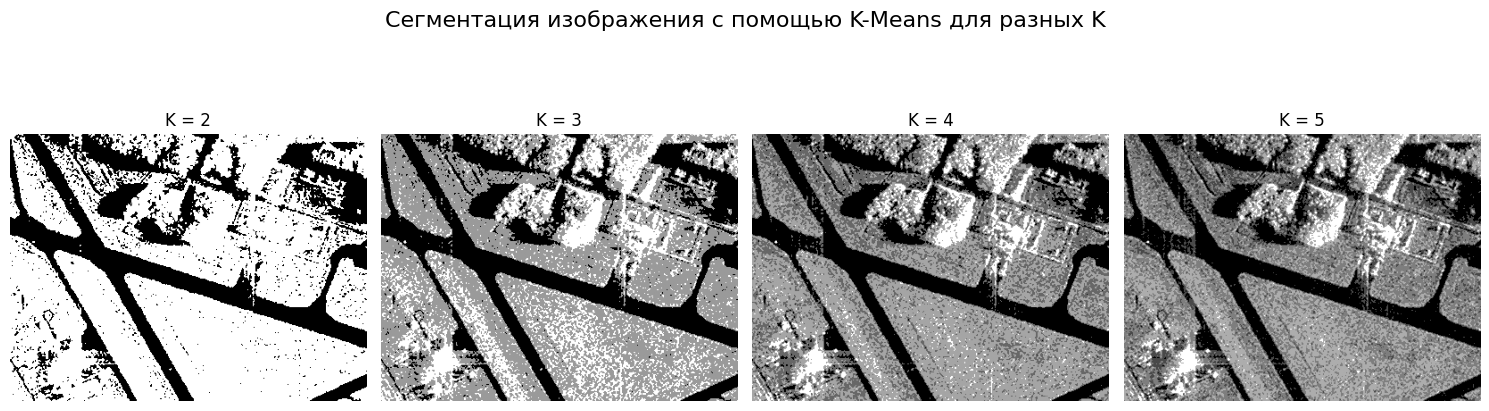

In [ ]:
# Функция для применения K-Means с заданным K
def apply_kmeans(image_gray, K):
    z = np.float32(image_gray.reshape((-1, 1)))
    
    # Критерий остановки: max_iter=100, eps=0.05
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.05)
    
    # Запуск K-Means
    ret, label, center = cv2.kmeans(z, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    
    # Постобработка: центры в uint8, замена пикселей на центры кластеров
    center = np.uint8(center)
    res = center[label.flatten()]
    res = res.reshape(image_gray.shape)
    
    return res

# Диапазон K: от 2 до 5
k_values = [2, 3, 4, 5]

fig, axs = plt.subplots(1, len(k_values), figsize=(15, 5))
fig.suptitle("Сегментация изображения с помощью K-Means для разных K", fontsize=16)
for idx, K in enumerate(k_values):
    segmented = apply_kmeans(image_gray, K)
    
    axs[idx].imshow(segmented, cmap="gray")
    axs[idx].set_title(f"K = {K}")
    axs[idx].axis('off')

plt.tight_layout()
plt.show()

### 3. Применить алгоритм сегментации watershed+distance transform для задачи подсчета пальмовых деревьев.

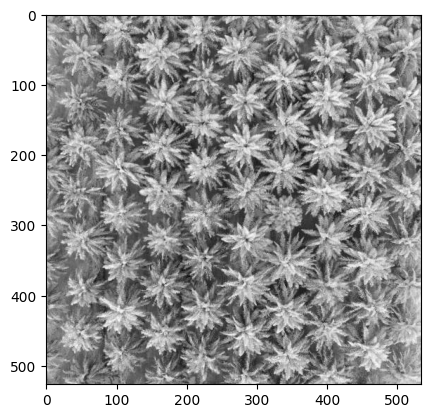

In [ ]:
image = cv2.imread('palm_1.JPG')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.imshow(image_gray, cmap="gray")

Параметры (blur=5, dist_mask=3, coeff=0.5): Подсчёт деревьев = 114
Параметры (blur=9, dist_mask=5, coeff=0.6): Подсчёт деревьев = 75
Параметры (blur=11, dist_mask=3, coeff=0.7): Подсчёт деревьев = 41


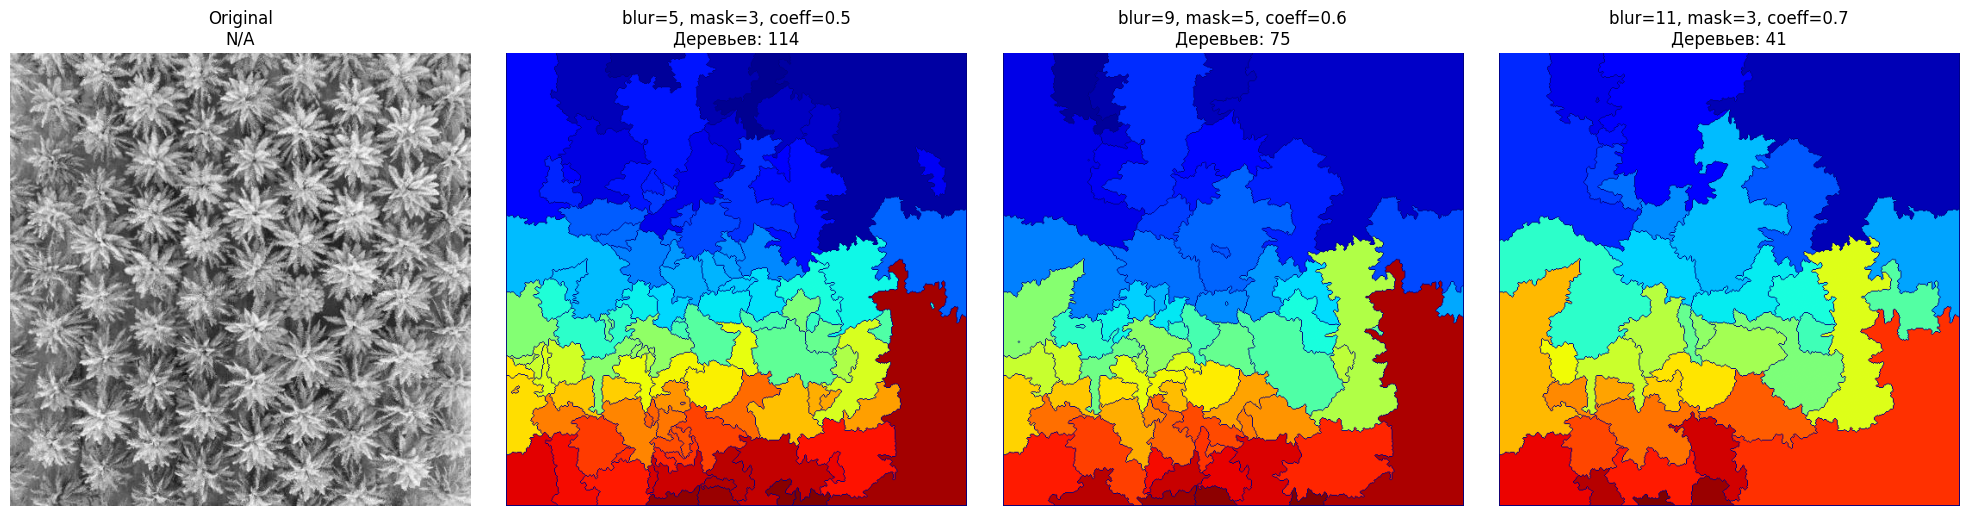

In [ ]:
# Функция для применения watershed с заданными параметрами
def apply_watershed(image, image_gray, blur_ksize, dist_mask, thresh_coeff):
    # Для снижения шума
    blurred = cv2.GaussianBlur(image_gray, (blur_ksize, blur_ksize), 0)
    
    # Бинаризация Otsu
    ret, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    # Distance Transform с разным mask size
    dist = cv2.distanceTransform(thresh, cv2.DIST_L2, dist_mask)
    
    # Threshold с разным коэффициентом
    ret, sure_fg = cv2.threshold(dist, thresh_coeff * dist.max(), 255, cv2.THRESH_BINARY)
    sure_fg = sure_fg.astype(np.uint8)
    ret, markers = cv2.connectedComponents(sure_fg)
    
    # Watershed
    markers = cv2.watershed(image, markers)
    
    # Подсчёт деревьев: уникальные маркеры минус фон
    unique = np.unique(markers)
    count = len(unique) - 1
    
    print(f"Параметры (blur={blur_ksize}, dist_mask={dist_mask}, coeff={thresh_coeff}): Подсчёт деревьев = {count}")
    
    return markers, count

# Список конфигураций параметров
param_configs = [
    {'blur_ksize': 5, 'dist_mask': 3, 'thresh_coeff': 0.5},
    {'blur_ksize': 9, 'dist_mask': 5, 'thresh_coeff': 0.6},
    {'blur_ksize': 11, 'dist_mask': 3, 'thresh_coeff': 0.7}
]

# Словарь для результатов
result_imgs = {'Original': image_gray}
counts = {}

for config in param_configs:
    markers, count = apply_watershed(image, image_gray, **config)
    name = f"blur={config['blur_ksize']}, mask={config['dist_mask']}, coeff={config['thresh_coeff']}"
    result_imgs[name] = markers
    counts[name] = count

# Визуализация
n_images = len(result_imgs)
fig, axes = plt.subplots(1, n_images, figsize=(5 * n_images, 5))

for idx, (name, img) in enumerate(result_imgs.items()):
    axes[idx].imshow(img, cmap='gray')
    size_str = f'Деревьев: {counts.get(name, "N/A")}' if name != 'Original' else 'N/A'
    axes[idx].set_title(f'{name}\n{size_str}')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()